# 1. Uvod u mašinsko učenje

## Šta je mašinsko učenje

Mašinsko učenje je oblast veštačke inteligencije koja omogućava računarskim sistemima da
**uče obrasce iz podataka** i donose odluke ili predikcije **bez eksplicitnog programiranja
pravila**.

$$\text{Podaci} + \text{algoritam} \rightarrow \text{model} \qquad
\text{Model} + \text{novi podaci} \rightarrow \text{predikcija}$$

### Definicija po Mitchell-u (1997)

> Računarski program uči iz **iskustva I** u odnosu na grupu **zadataka Z** i **meru
> performansi P**, ako se njegova performansa nad zadatkom iz Z poboljšava zahvaljujući
> iskustvu I.

**Primer — spam filter:**

| | |
|---|---|
| **Zadatak (Z)** | klasifikacija poruka na spam / not-spam |
| **Iskustvo (I)** | skup označenih poruka + označavanje od strane korisnika |
| **Performanse (P)** | procenat ispravno klasifikovanih poruka |

## Klasično programiranje vs. mašinsko učenje

| pristup | šta se zadaje | šta se dobija |
|---|---|---|
| klasično programiranje | Ulaz + **Pravila** | Izlaz |
| mašinsko učenje | Ulaz + **Izlaz** | **Pravila** |

Kod klasičnog programiranja logiku piše čovek. Kod mašinskog učenja logika se **uči iz podataka**.

## Odnos oblasti

- **Veštačka inteligencija (AI)** — široka oblast sistema koji pokazuju inteligentno ponašanje: pravila, ekspertski sistemi, planiranje, rezonovanje, mašinsko učenje
- **Mašinsko učenje (ML)** — podoblast AI; sistem uči obrasce iz podataka
- **Duboko učenje (DL)** — podoblast ML; višeslojne neuronske mreže
- **Nauka o podacima** — šira disciplina (prikupljanje, analiza, vizualizacija, odlučivanje) koja koristi ML kao jedan od alata

## Tipovi mašinskog učenja

- **Nadgledano učenje** (supervised) — imamo ulaz i **poznatu oznaku**
- **Nenadgledano učenje** (unsupervised) — nemamo oznake, tražimo strukturu
- **Polunadgledano učenje** (semi-supervised)
- **Učenje potkrepljenjem** (reinforcement learning)

### Nadgledano učenje

| problem | ciljna promenljiva | primer |
|---|---|---|
| **Klasifikacija** | kategorička | spam / not-spam, mačka / pas / ptica |
| **Regresija** | neprekidna | cena stana, temperatura |

### Nenadgledano učenje

| problem | algoritmi |
|---|---|
| **Klasterovanje** | k-means, hijerarhijsko, DBSCAN, Gaussian Mixture Models |
| **Redukcija dimenzionalnosti** | PCA, t-SNE, UMAP |
| **Procena gustine** | koliko je verovatno da se podatak pojavi na tom mestu u prostoru |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_diabetes

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
RS = 42

# --- primer skupa za KLASIFIKACIJU: kategoricka ciljna promenljiva ---
iris = load_iris(as_frame=True)
print("KLASIFIKACIJA — iris")
print(f"   X (ulaz)  : {iris.data.shape[0]} uzoraka x {iris.data.shape[1]} obelezja")
print(f"   y (izlaz) : klase {list(iris.target_names)}")
print(f"   raspodela : {np.bincount(iris.target).tolist()}")

# --- primer skupa za REGRESIJU: neprekidna ciljna promenljiva ---
dia = load_diabetes(as_frame=True)
print("\nREGRESIJA — diabetes")
print(f"   X (ulaz)  : {dia.data.shape[0]} uzoraka x {dia.data.shape[1]} obelezja")
print(f"   y (izlaz) : neprekidan, opseg [{dia.target.min():.0f}, {dia.target.max():.0f}]")

KLASIFIKACIJA — iris
   X (ulaz)  : 150 uzoraka x 4 obelezja
   y (izlaz) : klase [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
   raspodela : [50, 50, 50]

REGRESIJA — diabetes
   X (ulaz)  : 442 uzoraka x 10 obelezja
   y (izlaz) : neprekidan, opseg [25, 346]


## Osnovni pojmovi

**Ulaz $X$** — feature-i / atributi / obeležja. Vektor osobina koji opisuje jedan primer.
Mogu biti numerički ili kategorički.

**Izlaz $y$** — oznaka / target. Vrednost koju model treba da predvidi. Diskretna kod
klasifikacije, neprekidna kod regresije.

### Parametri vs. hiperparametri

| | parametri | hiperparametri |
|---|---|---|
| kada se određuju | **tokom** treniranja | **pre** treniranja |
| ko ih određuje | algoritam, iz podataka | mi |
| primeri | težine u regresiji i mreži | learning rate, dubina stabla, broj suseda $k$ |

In [2]:
X = iris.data
y = iris.target

print("X — prvih 5 redova:")
display(X.head())
print(f"\ny — prvih 10 oznaka: {y.values[:10]}")
print(f"\nJedan uzorak je vektor osobina duzine {X.shape[1]}:")
print(f"   {X.iloc[0].to_dict()}  ->  klasa {iris.target_names[y.iloc[0]]}")

X — prvih 5 redova:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



y — prvih 10 oznaka: [0 0 0 0 0 0 0 0 0 0]

Jedan uzorak je vektor osobina duzine 4:
   {'sepal length (cm)': 5.1, 'sepal width (cm)': 3.5, 'petal length (cm)': 1.4, 'petal width (cm)': 0.2}  ->  klasa setosa


## Podela podataka

| skup | uloga |
|---|---|
| **trening** | učenje modela |
| **validacioni** | izbor modela i podešavanje hiperparametara |
| **test** | **isključivo** konačna evaluacija; nije dostupan algoritmu ni u jednom delu učenja |

Uobičajene podele: 80/20 (train/test) ili 70/15/15 (train/val/test).

**Stratifikacija** čuva odnos klasa u svim skupovima — bitna kod neuravnoteženih podataka.

In [3]:
from sklearn.model_selection import train_test_split

# bez stratifikacije
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=1)
print("BEZ stratifikacije — raspodela klasa u test skupu:", np.bincount(yte).tolist())

# sa stratifikacijom
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
print("SA stratifikacijom  — raspodela klasa u test skupu:", np.bincount(yte).tolist())
print("\nOriginalna raspodela                             :", np.bincount(y).tolist())

BEZ stratifikacije — raspodela klasa u test skupu: [14, 18, 13]
SA stratifikacijom  — raspodela klasa u test skupu: [15, 15, 15]

Originalna raspodela                             : [50, 50, 50]


## Kros-validacija

Jedna podela na train/test daje **nestabilnu** procenu — rezultat zavisi od toga koji su
uzorci slučajno završili u testu.

**k-fold kros-validacija**: skup se deli na $k$ podskupova (foldova). Model se trenira
$k$ puta, svaki put je drugi fold validacioni. Konačni rezultat je **prosek**.

$$\text{Performansa} = \frac{1}{k}\sum_{i=1}^{k} \text{Performansa}_i$$

**LOOCV** (Leave-One-Out) je specijalan slučaj sa $k = n$ — svaki uzorak je jednom
validacioni. Maksimalno koristi podatke, ali je računski vrlo skup.

In [4]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, random_state=RS)

# jedna podela — nestabilna procena
pojedinacne = []
for seed in range(6):
    a, b, c, d = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)
    pojedinacne.append(model.fit(a, c).score(b, d))
print(f"6 razlicitih podela: {[round(s, 3) for s in pojedinacne]}")
print(f"   raspon: {min(pojedinacne):.3f} do {max(pojedinacne):.3f}  <- velika razlika!\n")

# 5-fold CV — stabilnija procena
cv = cross_val_score(model, X, y, cv=KFold(5, shuffle=True, random_state=RS))
print(f"5-fold CV: {cv.round(3).tolist()}")
print(f"   prosek {cv.mean():.3f} +- {cv.std():.3f}")

6 razlicitih podela: [0.956, 0.978, 0.956, 0.911, 0.978, 0.956]
   raspon: 0.911 do 0.978  <- velika razlika!

5-fold CV: [1.0, 0.967, 0.933, 0.9, 0.967]
   prosek 0.953 +- 0.034


## Overfitting i underfitting

| | trening greška | test greška | uzrok |
|---|---|---|---|
| **Underfitting** | velika | velika | model previše jednostavan |
| **Overfitting** | **mala** | **velika** | model previše složen, „nauči napamet" |

Cilj mašinskog učenja nije mala greška na treningu, nego **dobra generalizacija** na nove
podatke.

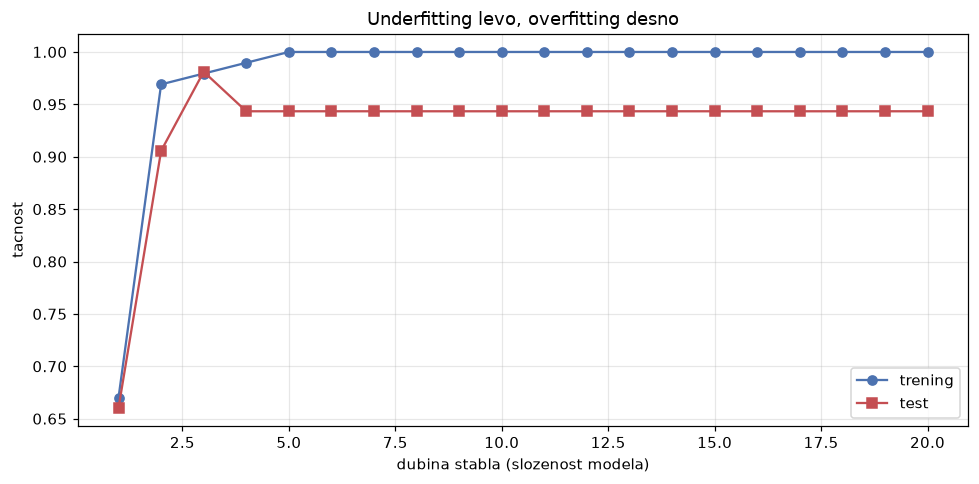

Dubina 1 : trening 0.670, test 0.660   <- UNDERFITTING
Dubina 20: trening 1.000, test 0.943   <- OVERFITTING


In [5]:
dubine = range(1, 21)
tr_rez, te_rez = [], []
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.35, random_state=RS, stratify=y)

for d in dubine:
    m = DecisionTreeClassifier(max_depth=d, random_state=RS).fit(Xtr, ytr)
    tr_rez.append(m.score(Xtr, ytr))
    te_rez.append(m.score(Xte, yte))

fig, ax = plt.subplots()
ax.plot(dubine, tr_rez, "o-", label="trening", color="#4C72B0")
ax.plot(dubine, te_rez, "s-", label="test", color="#C44E52")
ax.set_xlabel("dubina stabla (slozenost modela)"); ax.set_ylabel("tacnost")
ax.set_title("Underfitting levo, overfitting desno")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Dubina 1 : trening {tr_rez[0]:.3f}, test {te_rez[0]:.3f}   <- UNDERFITTING")
print(f"Dubina 20: trening {tr_rez[-1]:.3f}, test {te_rez[-1]:.3f}   <- OVERFITTING")

## Tok rada u mašinskom učenju (ML pipeline)

1. Prikupljanje podataka
2. Čišćenje podataka
3. Feature engineering
4. Podela skupa (train / validation / test)
5. Treniranje modela
6. Evaluacija
7. Deployment
8. Monitoring

## Četiri česte greške u praksi

1. **Data leakage** — informacija iz test skupa procuri u obuku
2. **Treniranje na test skupu**
3. **Overfitting**
4. **Pogrešne metrike** — npr. tačnost kod jako neuravnoteženih klasa

## Objašnjiva veštačka inteligencija (XAI)

Modeli često funkcionišu kao **crna kutija**. Interpretabilnost je važna zbog:
poverenja korisnika, regulative, i otkrivanja grešaka i pristrasnosti.

Pristupi: interpretabilni modeli (stabla) i post-hoc objašnjenja (SHAP, LIME).
Detaljno u predavanju 13.